In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


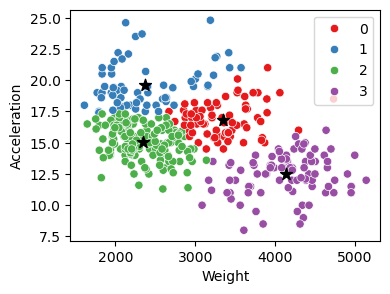

In [2]:
df = pd.read_csv('./data/car_miles_per_gallon.csv')
df2 = df[['Weight','Acceleration']].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df3 = pd.DataFrame()
df3[['Weight','Acceleration']] = scaler.fit_transform(df2)

from sklearn.cluster import KMeans
model = KMeans(n_clusters = 4)
model.fit(df3)

center = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=[4,3])
sns.scatterplot(data=df,x='Weight',y='Acceleration', hue=model.labels_,palette='Set1')
plt.scatter(center[:,0],center[:,1],s=80, marker='*', c='k')
plt.show()

In [3]:
from sklearn.metrics import silhouette_score

In [4]:
score = silhouette_score(df3,model.labels_)
score

0.4157345903483939

In [5]:
#silh = b-a/max(b,a)

In [6]:
from sklearn.cluster import KMeans

for k in range(2,11):
    model = KMeans(n_clusters = k)
    model.fit(df3)
    score = silhouette_score(df3,model.labels_)
    print('k = {} : score = {} '.format(k,score))

k = 2 : score = 0.4838500863834756 
k = 3 : score = 0.4174082819334329 
k = 4 : score = 0.4157345903483939 
k = 5 : score = 0.3986033644452572 
k = 6 : score = 0.3787984930894841 
k = 7 : score = 0.374650428429267 
k = 8 : score = 0.3726156999805734 
k = 9 : score = 0.35600865855998415 
k = 10 : score = 0.365907832647077 


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [7]:
df = pd.read_excel('./data/shirt_size.xlsx')

In [8]:
df.head()

,Height_cms,Weight_kgs,T_Shirt_Size
0,158,58,M
1,158,59,M
2,160,64,L
3,163,64,L
4,165,61,L


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Height_cms    18 non-null     int64 
 1   Weight_kgs    18 non-null     int64 
 2   T_Shirt_Size  18 non-null     object
dtypes: int64(2), object(1)
memory usage: 564.0+ bytes


In [10]:
att = df[['Height_cms','Weight_kgs']]
label = df['T_Shirt_Size']

In [11]:
from sklearn.neighbors import KNeighborsClassifier #KNN

In [12]:
model = KNeighborsClassifier(n_neighbors= 5 )
model.fit(att,label)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
model.predict([[170,60]]) ###predict size of shirt 

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['L'], dtype=object)

In [14]:
label_predict = model.predict(att)

In [15]:
pd.DataFrame({'Class':label.values,'Predeict':label_predict})

,Class,Predeict
0,M,M
1,M,M
2,L,M
3,L,L
4,L,L
5,M,M
6,M,M
7,L,L
8,L,L
9,M,M


In [16]:
from sklearn.metrics import accuracy_score

In [17]:
accuracy_score(label,label_predict) ###cal the accuracy of model

0.8888888888888888

In [18]:
###imbalanced slass

In [19]:
df = pd.read_excel('./data/fruit_data.xlsx')

In [20]:
df.head()

,width,height,mass,color_score,fruit_name
0,8.4,7.3,192,0.55,apple
1,6.2,4.7,86,0.80,mandarin
2,6.0,4.6,84,0.79,mandarin
3,8.0,6.8,180,0.59,apple
4,7.4,7.2,176,0.60,apple


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   width        59 non-null     float64
 1   height       59 non-null     float64
 2   mass         59 non-null     int64  
 3   color_score  59 non-null     float64
 4   fruit_name   59 non-null     object 
dtypes: float64(3), int64(1), object(1)
memory usage: 2.4+ KB


In [22]:
df['fruit_name'].value_counts()

fruit_name
apple       19
orange      19
lemon       16
mandarin     5
Name: count, dtype: int64

In [23]:
###under sampling

In [24]:
df.groupby('fruit_name').sample(n=10 ,replace=True)

,width,height,mass,color_score,fruit_name
20,7.5,7.5,160,0.86,apple
21,7.4,7.4,156,0.84,apple
14,7.6,7.3,152,0.69,apple
15,7.7,7.1,156,0.69,apple
18,7.5,7.1,162,0.83,apple
0,8.4,7.3,192,0.55,apple
21,7.4,7.4,156,0.84,apple
9,7.4,7.0,172,0.89,apple
23,7.6,7.9,170,0.88,apple
21,7.4,7.4,156,0.84,apple


In [25]:
##over sampling

In [26]:
from imblearn.over_sampling import SMOTE

In [27]:
smote = SMOTE(k_neighbors= 5 )

In [28]:
att = df[['width','height','mass','color_score']]
label = df['fruit_name']

In [29]:
att_new,label_new = smote.fit_resample(att,label)

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 5, n_samples = 5

In [ ]:
df_balance = pd.DataFrame(att_new,columns=['width','height','mass','color_score'])
df_balance['fruit_name'] = label_new
df_balance

In [ ]:
label_new.value_counts()

In [ ]:
plt.figure(figsize=[4,3])
sns.scatterplot(df,x='width',y='height',hue='fruit_name')

In [ ]:
plt.figure(figsize=[4,3])
sns.scatterplot(df_balance,x='width',y='height',hue='fruit_name')

In [ ]:
df = pd.read_excel('./data/animals.xlsx')

In [ ]:
df.head(3)

In [ ]:
df['Live_In_Water'].unique()

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
OE = OrdinalEncoder(categories= [['No', 'Sometimes', 'Yes']]) ###0 1 2 need to sort by seq to seq

In [ ]:
df['Live_In_Water'] = OE.fit_transform(df[['Live_In_Water']])

In [ ]:
df.head()

In [ ]:
df['Species'].unique()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
OHE = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform = 'pandas')
new_df = OHE.fit_transform(df[['Species']])

In [ ]:
new_df

In [ ]:
df2 = pd.concat([df,new_df],axis=1)
df2.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
att = df.iloc[:,:-1]
label = df.iloc[:,:-1]

In [ ]:
att_train,att_test ,label_train ,label_test = train_test_split(att,label,train_size=0.8)

In [ ]:
df = pd.read_excel('./data/customer.xlsx')

In [ ]:
df.head()

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
OE = OrdinalEncoder(categories= [['Male', 'Female']])
df['gender'] = OE.fit_transform(df[['gender']])

In [ ]:
df.head()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2 = pd.DataFrame()
df2 = df.iloc[:,:-1]
df3 = pd.DataFrame()
df3[['gender','age','salary']] = scaler.fit_transform(df2)

In [ ]:
df.columns

In [ ]:
att = df3
label = df.iloc[:,-1]

In [ ]:
label

In [ ]:
from sklearn.model_selection import train_test_split
att_train,att_test ,label_train ,label_test = train_test_split(att,label,train_size=0.8)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors= 5)
model.fit(att_train,label_train)

In [ ]:
label_predict = model.predict(att_test)
from sklearn.metrics import accuracy_score
accuracy_score(label_test,label_predict)

In [ ]:
model.predict(scaler.transform([[1,49,36000]]))

In [ ]:
df = pd.read_excel('./data/customer.xlsx')

from sklearn.preprocessing import OrdinalEncoder

OE = OrdinalEncoder(categories=[['Male','Female']])
df['gender']=OE.fit_transform(df[['gender']])

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df2=pd.DataFrame()
df2=df.iloc[:,:-1]
df3=pd.DataFrame()
df3[['gender','age','salary']]=scaler.fit_transform(df2)

att =df3
label = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
att_train,att_test,label_train,label_test=train_test_split(att,label,train_size=0.8)

from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(att_train,label_train)

label_predict = model.predict(att_test)
from sklearn.metrics import accuracy_score
accuracy_score(label_test,label_predict)


In [ ]:
model.predict(scaler.transform([[0,50,200000]]))

In [ ]:
display(pd.DataFrame({'Class':label_test.values,'Predict':label_predict}))

In [ ]:
###how to devived train or test will be stable use cross validation

In [ ]:
###cross validation

In [ ]:
df = pd.read_excel('./data/customer.xlsx')

from sklearn.preprocessing import OrdinalEncoder

OE = OrdinalEncoder(categories=[['Male','Female']])
df['gender']=OE.fit_transform(df[['gender']])

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df2=pd.DataFrame()
df2=df.iloc[:,:-1]
df3=pd.DataFrame()
df3[['gender','age','salary']]=scaler.fit_transform(df2)

att =df3
label = df.iloc[:,-1]


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

In [ ]:
skf = StratifiedKFold(n_splits= 5,shuffle=True)
scores = cross_val_score(model,att,label,cv=skf)

In [ ]:
scores

In [ ]:
df = pd.read_excel('./data/customer.xlsx')

from sklearn.preprocessing import OrdinalEncoder

OE = OrdinalEncoder(categories=[['Male','Female']])
df['gender']=OE.fit_transform(df[['gender']])

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df2=pd.DataFrame()
df2=df.iloc[:,:-1]
df3=pd.DataFrame()
df3[['gender','age','salary']]=scaler.fit_transform(df2)

att =df3
label = df.iloc[:,-1]

from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

skf = StratifiedKFold(n_splits= 5,shuffle=True)
scores = cross_val_score(model,att,label,cv=skf)

scores.mean()

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# อ่านไฟล์
df = pd.read_excel('./data/reptile.xlsx')

# แปลง gender เป็นตัวเลข
OE = OrdinalEncoder(categories=[['Male', 'Female']])
df['gender'] = OE.fit_transform(df[['gender']])

# กำหนด features และ label
X = df[['temperature', 'gender']]
y = df['water']

# สร้าง Pipeline (กัน Data Leakage)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Stratified 5-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross Validation
scores = cross_val_score(model, X, y, cv=skf)

# แสดงผล
print("Accuracy แต่ละ fold:", scores)
print("Accuracy เฉลี่ย:", scores.mean())

In [ ]:
df = pd.read_csv('./data/car_miles_per_gallon.csv')

In [ ]:
df.head(5)

In [ ]:
df.info()

In [ ]:
###use 1 2 3 4 5 columns for predict 1 column

In [ ]:
sns.pairplot(df)

In [ ]:
###look into sth that can use to plot sth like group

In [ ]:
x = df[['Weight']]
y = df['MPG']

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x,y)

In [ ]:
model.predict([[3000]])

In [ ]:
x_range = np.linspace(1500,5000,100).reshape(-1,1) ###ทำให้เป็นแนวตั้งจากตอนแรกเป็นค่า 100 ตัว 
y_predict = model.predict(x_range)
plt.scatter(x,y)
plt.plot(x_range,y_predict,c='r')

In [ ]:
df = pd.read_csv('./data/car_miles_per_gallon.csv')

x = df[['Weight']]
y = df['MPG']

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x,y)

from sklearn.metrics import mean_absolute_error
y_predict = model.predict(x)
score = mean_absolute_error(y,y_predict)
print(score)